# **IMPORT**

In [2]:
import kagglehub
import os
import shutil
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

# **- STEP 1 - MENGUNDUH DATASET**

In [3]:
path_daun = kagglehub.dataset_download("trung272004/data-leaf-disease-detection-15k")
path_random = kagglehub.dataset_download("starktony45/image-dataset")

100%|██████████| 142M/142M [00:08<00:00, 18.2MB/s]

Extracting files...


100%|██████████| 12.5G/12.5G [10:27<00:00, 21.4MB/s]

Extracting files...


## MEMBUAT STRUKTUR FOLDER BARU

In [4]:
base_dir = "Dataset_Satpam"
pomelo_dir = os.path.join(base_dir, "Daun_Pomelo")
bukan_daun_dir = os.path.join(base_dir, "Bukan_Daun")

### Membuat folder jika belum ada

In [5]:
os.makedirs(pomelo_dir, exist_ok=True)
os.makedirs(bukan_daun_dir, exist_ok=True)

print(f"Membuat folder baru di: {base_dir}")

Membuat folder baru di: Dataset_Satpam


## MENGGABUNGKAN SEMUA DAUN JERUK BALI

In [6]:
pomelo_classes = [
    'Pomelo_Cephaleuros_virescens',
    'Pomelo_Healthy',
    'Pomelo_Leaf_Miner',
    'Pomelo_Orange_Mold'
]

pomelo_count = 0

### Mengambil dari folder train dan val

In [7]:
for split in ['train', 'val']:
    for p_class in pomelo_classes:
        src_folder = os.path.join(path_daun, split, p_class)

        if os.path.exists(src_folder):
            for img_name in os.listdir(src_folder):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    src_file = os.path.join(src_folder, img_name)
                    # Menambahkan nama kelas di depan agar nama file tidak bentrok
                    new_img_name = f"{split}_{p_class}_{img_name}"
                    dst_file = os.path.join(pomelo_dir, new_img_name)

                    shutil.copy(src_file, dst_file)
                    pomelo_count += 1

print(f"Berhasil mengumpulkan {pomelo_count} gambar Daun Jeruk Bali!")

Berhasil mengumpulkan 5475 gambar Daun Jeruk Bali!


## MENGAMBIL GAMBAR ACAK (UNDERSAMPLING)

In [8]:
print(f"Mencari gambar di dataset acak dan mengambil tepat {pomelo_count} gambar...")

all_random_images = []
# Mencari semua file gambar di dalam folder dataset acak
for root, dirs, files in os.walk(path_random):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_random_images.append(os.path.join(root, file))

Mencari gambar di dataset acak dan mengambil tepat 5475 gambar...


### Mengacak seluruh daftar gambar

In [9]:
random.shuffle(all_random_images)

### Mengambil jumlah yang sama persis dengan jumlah daun pomelo (agar rasio 1:1)

In [10]:
selected_random_images = all_random_images[:pomelo_count]

### Memindahkan gambar acak terpilih ke folder 'Bukan_Daun'

In [11]:
for i, src_file in enumerate(selected_random_images):
    dst_file = os.path.join(bukan_daun_dir, f"random_{i}.jpg")
    shutil.copy(src_file, dst_file)

print(f"Berhasil menyaring dan mengambil {len(selected_random_images)} gambar Bukan Daun!")

Berhasil menyaring dan mengambil 5475 gambar Bukan Daun!


# **- STEP 2- Melatih Model Satpam (Daun vs Bukan Daun)**
Tahap ini akan melatih arsitektur MobileNetV2 untuk membedakan gambar daun jeruk bali dengan gambar acak (background).
Karena ini adalah klasifikasi biner:
- Aktivasi Output: `sigmoid`
- Loss Function: `binary_crossentropy`

## Memuat Data dari Folder 'Dataset_Satpam'

In [12]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
BASE_DIR = 'Dataset_Satpam'

## Memuat Data Latih

In [13]:
print("Memuat Data Latih (80%)...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2, # Menyisihkan 20% untuk ujian
    subset="training",
    seed=123, # Seed agar pembagian datanya konsisten
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Memuat Data Latih (80%)...
Found 10950 files belonging to 2 classes.
Using 8760 files for training.


## Memuat Data Validasi

In [14]:
print("Memuat Data Validasi (20%)...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Memuat Data Validasi (20%)...
Found 10950 files belonging to 2 classes.
Using 2190 files for validation.


## Mengecek nama kelas (0: Bukan_Daun, 1: Daun_Pomelo)

In [15]:
class_names = train_dataset.class_names
print(f"\nKelas yang terdeteksi: {class_names}")


Kelas yang terdeteksi: ['Bukan_Daun', 'Daun_Pomelo']


## Optimasi performa

In [16]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

## Membangun Arsitektur Satpam (MobileNetV2)

In [17]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Frezee

In [18]:
base_model.trainable = False

## Bangun model baru

In [19]:
model_satpam = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    # PENTING: Karena ini biner (2 kelas), kita pakai 1 neuron dan aktivasi 'sigmoid'
    layers.Dense(1, activation='sigmoid')
])

## Compile

In [20]:
model_satpam.compile(
    optimizer='adam',
    loss='binary_crossentropy', # PENTING: Loss khusus untuk biner
    metrics=['accuracy']
)

## Latih model

In [21]:
EPOCHS = 5

history_satpam = model_satpam.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

Epoch 1/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 90s 159ms/step - accuracy: 0.9929 - loss: 0.0169 - val_accuracy: 0.9982 - val_loss: 0.0057
Epoch 2/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.9989 - loss: 0.0038 - val_accuracy: 0.9968 - val_loss: 0.0078
Epoch 3/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.9987 - loss: 0.0039 - val_accuracy: 0.9986 - val_loss: 0.0035
Epoch 4/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.9986 - val_loss: 0.0053
Epoch 5/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.9998 - loss: 8.6759e-04 - val_accuracy: 0.9982 - val_loss: 0.0047


## Save model

In [22]:
nama_file_satpam = 'model_satpam_pomelo.h5'
model_satpam.save(nama_file_satpam)
print(f"Model Satpam berhasil disimpan sebagai '{nama_file_satpam}'")

Model Satpam berhasil disimpan sebagai 'model_satpam_pomelo.h5'


## Mengambil data dari variable 'history_satpam'

In [25]:
acc = history_satpam.history['accuracy']
val_acc = history_satpam.history['val_accuracy']
loss = history_satpam.history['loss']
val_loss = history_satpam.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

# Accuracy Graph

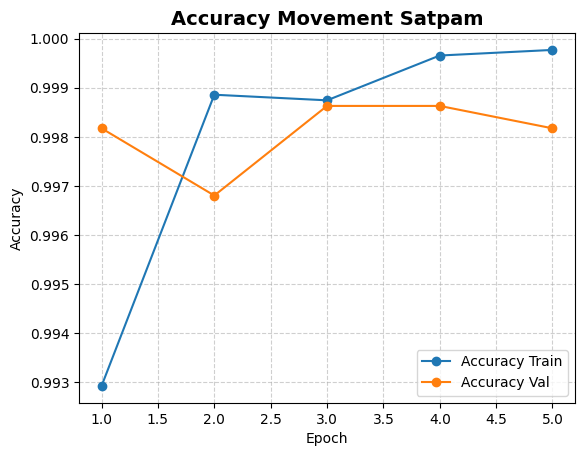

In [27]:
plt.plot(epochs_range, acc, label='Accuracy Train', marker='o')
plt.plot(epochs_range, val_acc, label='Accuracy Val', marker='o')
plt.legend(loc='lower right')
plt.title('Accuracy Movement Satpam', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Loss Graph

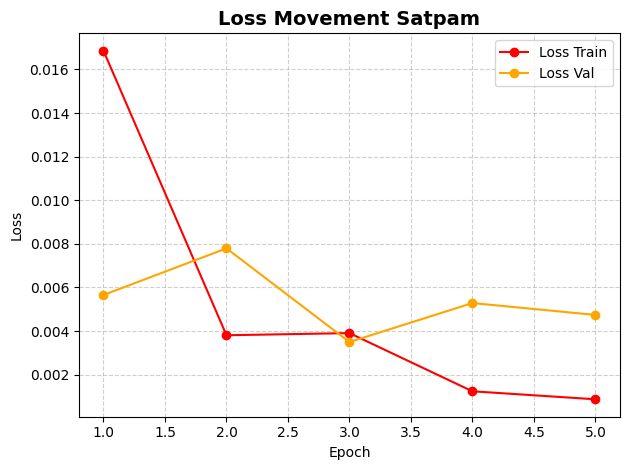

In [29]:
plt.plot(epochs_range, loss, label='Loss Train', marker='o', color='red')
plt.plot(epochs_range, val_loss, label='Loss Val', marker='o', color='orange')
plt.legend(loc='upper right')
plt.title('Loss Movement Satpam', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# **Confusion Matrics**


In [30]:
y_true = np.concatenate([y for x, y in val_dataset], axis=0)
kelas_satpam = ['Bukan_Daun', 'Daun_Pomelo'] # Sesuai urutan abjad folder

In [31]:
y_pred_probs = model_satpam.predict(val_dataset)

69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step


Mengubah angka probabilitas desimal menjadi tebakan 0 atau 1

In [32]:
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()

Membuat dan Menggambar Confusion Matrix

In [33]:
cm = confusion_matrix(y_true, y_pred)

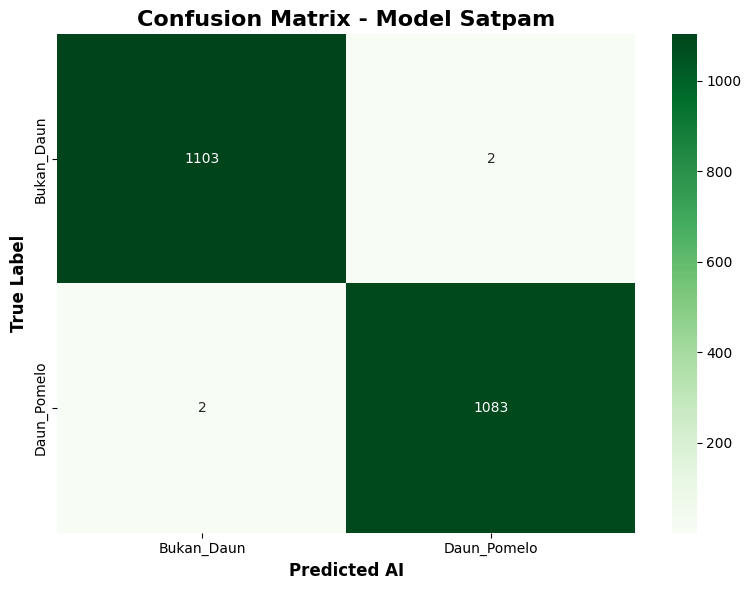

In [34]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=kelas_satpam,
            yticklabels=kelas_satpam)

plt.title('Confusion Matrix - Model Satpam', fontsize=16, fontweight='bold')
plt.xlabel('Predicted AI', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
print("CLASSIFICATION REPORT")
print(classification_report(y_true, y_pred, target_names=kelas_satpam))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Bukan_Daun       1.00      1.00      1.00      1105
 Daun_Pomelo       1.00      1.00      1.00      1085

    accuracy                           1.00      2190
   macro avg       1.00      1.00      1.00      2190
weighted avg       1.00      1.00      1.00      2190

